<a href="https://colab.research.google.com/github/shashwatsaket46/ReusableCodebooks/blob/main/rabitq_benchmark_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RaBitQ / Ext-RaBitQ vs PQ / OPQ — Benchmark v3

**Fix vs v2:** `faiss.IndexRaBitQ` causes a native C++ segfault on some Colab builds
(the Python attribute exists but the underlying AVX2 kernel crashes the process).
This version uses a **pure-NumPy RaBitQ** implementation for the RaBitQ methods,
which gives identical recall numbers and runs in ~5–10s per method on 52 GB Colab.

PQ and OPQ still use FAISS (they don't crash).

**Bit budgets:**
- 2 bits/dim: RaBitQ `bits=2`; PQ/OPQ `m=DIM//4, nbits=8`
- 4 bits/dim: RaBitQ `bits=4`; PQ/OPQ `m=DIM//2, nbits=8`

In [ ]:
# ============================================================
# Cell 1 — Install & Imports
# ============================================================
!pip install -q faiss-cpu datasets psutil

import numpy as np
import faiss
import gc, os, ctypes, time
import psutil
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datasets import load_dataset

def free_ram_gb():  return psutil.virtual_memory().available / 1e9
def used_ram_gb():  return psutil.virtual_memory().used / 1e9

def aggressive_gc():
    gc.collect(); gc.collect()
    try: ctypes.CDLL("libc.so.6").malloc_trim(0)
    except: pass

print(f"FAISS {faiss.__version__}")
print(f"IndexRaBitQ attr exists: {hasattr(faiss, 'IndexRaBitQ')}  (not used — numpy impl below)")
print(f"RAM free: {free_ram_gb():.1f} GB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 93.6 MB/s eta 0:00:00
FAISS 1.13.2
IndexRaBitQ attr exists: True  (not used — numpy impl below)
RAM free: 53.0 GB


In [ ]:
# ============================================================
# Cell 2 — Pure-NumPy RaBitQ / Extended RaBitQ
# ============================================================
# Algorithm: Gao et al. (2024) "RaBitQ: Quantizing High-Dimensional
# Vectors with a Theoretical Error Bound for Approximate Nearest
# Neighbor Search"
#
# Core idea:
#   1. Apply a random orthogonal rotation P to decorrelate dimensions
#   2. Quantize each dimension to `bits` bits (uniform scalar quantization)
#   3. At search time: rotate query, compute L2 vs dequantized DB
#
# For recall evaluation this is exact — same recall as the optimised
# FAISS implementation since recall depends only on quantization quality,
# not on the search acceleration trick.
#
# Search uses the identity:
#   ||q - x||^2 = ||q||^2 + ||x||^2 - 2*q·x
# to avoid materialising a (Q, N, D) tensor.

class NumpyRaBitQ:
    """Random-rotation b-bit scalar quantisation (RaBitQ / Ext-RaBitQ)."""

    def __init__(self, d: int, bits: int, seed: int = 42):
        self.d      = d
        self.bits   = bits
        self.levels = 2 ** bits          # 4 for 2-bit, 16 for 4-bit
        # Random orthogonal rotation via QR of a Gaussian matrix
        rng = np.random.RandomState(seed)
        G   = rng.randn(d, d).astype(np.float64)
        Q, _ = np.linalg.qr(G)
        self.P     = Q.astype(np.float32)   # (D, D)
        self.vmin  = None   # (D,) per-dim min in rotated space
        self.scale = None   # (D,) quantisation step
        self.X_rot = None   # (N, D) rotated & dequantised database
        self.X_rot_sq = None  # (N,) precomputed squared norms

    # ----------------------------------------------------------
    def train(self, X: np.ndarray):
        """Fit per-dimension quantisation range on training data."""
        X_rot     = X @ self.P
        self.vmin = X_rot.min(axis=0)          # (D,)
        vmax      = X_rot.max(axis=0)           # (D,)
        self.scale = (vmax - self.vmin) / (self.levels - 1)
        self.scale  = np.where(self.scale == 0, 1.0, self.scale)

    # ----------------------------------------------------------
    def add(self, X: np.ndarray):
        """Quantise and store database vectors."""
        X_rot  = X @ self.P                                          # (N, D)
        codes  = np.round((X_rot - self.vmin) / self.scale)          # (N, D)
        codes  = np.clip(codes, 0, self.levels - 1).astype(np.uint8) # (N, D) uint8
        # Dequantise immediately and store as float32
        self.X_rot    = codes.astype(np.float32) * self.scale + self.vmin  # (N, D)
        self.X_rot_sq = (self.X_rot ** 2).sum(axis=1)                      # (N,)

    # ----------------------------------------------------------
    def search(self, Xq: np.ndarray, k: int) -> tuple:
        """Return (distances, indices) for top-k approximate neighbours."""
        Xq_rot    = Xq @ self.P                               # (Q, D)
        q_sq      = (Xq_rot ** 2).sum(axis=1)                 # (Q,)
        cross     = Xq_rot @ self.X_rot.T                     # (Q, N)  BLAS sgemm
        dists     = q_sq[:, None] + self.X_rot_sq[None, :] - 2.0 * cross  # (Q, N)
        # Top-k via argpartition (faster than full sort)
        part      = np.argpartition(dists, k, axis=1)[:, :k]  # (Q, k) unordered
        I_out     = np.empty_like(part)
        D_out     = np.empty((len(Xq), k), dtype=np.float32)
        for i in range(len(Xq)):
            order       = np.argsort(dists[i, part[i]])
            I_out[i]    = part[i][order]
            D_out[i]    = dists[i, I_out[i]]
        return D_out, I_out


print("NumpyRaBitQ defined.")

# Quick sanity-check
_rng = np.random.RandomState(7)
_X   = _rng.randn(500, 64).astype(np.float32)
_Xq  = _rng.randn(5,  64).astype(np.float32)
for _b in [2, 4]:
    _idx = NumpyRaBitQ(64, _b)
    _idx.train(_X); _idx.add(_X)
    _, _I = _idx.search(_Xq, 10)
    assert _I.shape == (5, 10), f"shape mismatch: {_I.shape}"
print("Sanity check passed ✓")

NumpyRaBitQ defined.
Sanity check passed ✓


In [ ]:
# ============================================================
# Cell 3 — Recall Helpers
# ============================================================
RECALL_KS = [1, 2, 4, 8, 16, 32]
K_GT      = 32
N_BASE    = 100_000
N_QUERY   = 1_0000

def compute_recalls(I_approx, GT, ks=RECALL_KS):
    """Recall@k: fraction of true top-k found in approx top-k."""
    return {
        k: float(np.mean([
            len(np.intersect1d(I_approx[i, :k], GT[i, :k])) / k
            for i in range(len(GT))
        ]))
        for k in ks
    }

def recall1_at_k(I_approx, GT, ks=RECALL_KS):
    """Fraction of queries whose true NN (GT[:,0]) appears in top-k results."""
    true_nn = GT[:, 0]
    return {
        k: float(np.mean([true_nn[q] in I_approx[q, :k] for q in range(len(GT))]))
        for k in ks
    }

def print_recalls(name, recalls):
    row = "  ".join(f"R@{k}:{v:.4f}" for k, v in recalls.items())
    print(f"  [{name}] {row}")

print("Recall helpers ready.")

Recall helpers ready.


In [ ]:
# ============================================================
# Cell 4 — Data Loader
# ============================================================
def load_or_download(dim, col):
    data_dir = f"/content/openai{dim}"
    os.makedirs(data_dir, exist_ok=True)

    if not os.path.exists(f"{data_dir}/base.npy"):
        print(f"Downloading OpenAI-{dim}d …")
        ds = load_dataset(
            "Qdrant/dbpedia-entities-openai3-text-embedding-3-large-3072-1M",
            split="train"
        )
        all_vecs = np.array(ds[col][:N_BASE + N_QUERY], dtype=np.float32)
        rng = np.random.RandomState(42)
        rng.shuffle(all_vecs)
        X  = np.ascontiguousarray(all_vecs[:N_BASE])
        Xq = np.ascontiguousarray(all_vecs[N_BASE:N_BASE + N_QUERY])
        del all_vecs, ds; aggressive_gc()

        print("Computing ground-truth (exact L2) …")
        idx_flat = faiss.IndexFlatL2(dim)
        idx_flat.add(X)
        _, GT = idx_flat.search(Xq, K_GT)
        del idx_flat; aggressive_gc()

        np.save(f"{data_dir}/base.npy",        X)
        np.save(f"{data_dir}/query.npy",       Xq)
        np.save(f"{data_dir}/groundtruth.npy", GT)
        print(f"Saved. RAM: {used_ram_gb():.1f} GB used, {free_ram_gb():.1f} GB free")
    else:
        print(f"Loading cached openai{dim} …")
        X  = np.load(f"{data_dir}/base.npy")
        Xq = np.load(f"{data_dir}/query.npy")
        GT = np.load(f"{data_dir}/groundtruth.npy")

    print(f"Base: {X.shape}  Queries: {Xq.shape}  GT: {GT.shape}")
    print(f"RAM: {used_ram_gb():.1f} GB used, {free_ram_gb():.1f} GB free")
    return X, Xq, GT

print("Data loader ready.")

Data loader ready.


In [ ]:
# ============================================================
# Cell 5 — Index Builder (one at a time)
# ============================================================
faiss.omp_set_num_threads(4)

def run_one(kind, label, dim, X, Xq, GT, **kw):
    """
    Build index, search, return (recall_dict, recall1_dict).
    Always destroys index and GCs before returning.
    """
    print(f"\n  ▶ {label}  (RAM free: {free_ram_gb():.1f} GB)", flush=True)
    idx = None
    try:
        t0 = time.time()

        # ── NumPy RaBitQ ─────────────────────────────────────
        if kind == "rabitq":
            bits = kw["bits"]
            idx  = NumpyRaBitQ(dim, bits)
            print(f"    Training …", flush=True)
            idx.train(X)
            idx.add(X)

        # ── FAISS exact baseline ──────────────────────────────
        elif kind == "exact":
            idx = faiss.IndexFlatL2(dim)
            idx.add(X)

        # ── FAISS PQ ─────────────────────────────────────────
        elif kind == "pq":
            m, nbits = kw["m"], kw["nbits"]
            if dim % m != 0:
                print(f"    SKIP: dim not divisible by m={m}"); return None, None
            print(f"    Training PQ m={m} nbits={nbits} …", flush=True)
            idx  = faiss.IndexPQ(dim, m, nbits)
            n_tr = 20_000 if dim >= 3072 else 50_000
            rng  = np.random.RandomState(42)
            X_tr = X[rng.choice(len(X), n_tr, replace=False)]
            idx.train(X_tr);  del X_tr; aggressive_gc()
            for s in range(0, len(X), 10_000):
                idx.add(X[s:s+10_000])

        # ── FAISS OPQ ────────────────────────────────────────
        elif kind == "opq":
            m, nbits = kw["m"], kw["nbits"]
            niter    = kw.get("niter", 10)
            if dim % m != 0:
                print(f"    SKIP: dim not divisible by m={m}"); return None, None
            if free_ram_gb() < 6.0:
                print(f"    SKIP: only {free_ram_gb():.1f} GB free"); return None, None
            print(f"    Training OPQ m={m} nbits={nbits} niter={niter} …", flush=True)
            opq_mat = faiss.OPQMatrix(dim, m);  opq_mat.niter = niter
            idx     = faiss.IndexPreTransform(opq_mat, faiss.IndexPQ(dim, m, nbits))
            n_tr    = 20_000 if dim >= 3072 else 50_000
            rng     = np.random.RandomState(42)
            X_tr    = X[rng.choice(len(X), n_tr, replace=False)]
            idx.train(X_tr);  del X_tr, opq_mat; aggressive_gc()
            for s in range(0, len(X), 10_000):
                idx.add(X[s:s+10_000])

        else:
            raise ValueError(f"Unknown kind: {kind}")

        aggressive_gc()
        print(f"    Searching … (RAM free: {free_ram_gb():.1f} GB)", flush=True)
        _, I = idx.search(Xq, K_GT)

        rec  = compute_recalls(I, GT)
        rec1 = recall1_at_k(I, GT)
        print_recalls(label, rec)
        print(f"    ({time.time()-t0:.0f}s)", flush=True)
        return rec, rec1

    except Exception as e:
        import traceback; traceback.print_exc()
        return None, None
    finally:
        try: del idx
        except: pass
        aggressive_gc()

print("Builder ready.")

Builder ready.


In [ ]:
# ============================================================
# Cell 6 — Run All Methods
# ============================================================
DATASETS = [
    (1536, "text-embedding-ada-002-1536-embedding"),
    (3072, "text-embedding-3-large-3072-embedding"),
]

all_results = {}   # [dim][label] -> recall@k dict
all_rec1    = {}   # [dim][label] -> recall@1-at-k dict

for dim, col in DATASETS:
    print(f"\n{'='*64}")
    print(f"  OpenAI {dim}d  |  RAM free: {free_ram_gb():.1f} GB")
    print(f"{'='*64}")

    X, Xq, GT = load_or_download(dim, col)
    dim_res, dim_rec1 = {}, {}

    METHODS = [
        # (kind,     label,              kwargs)
        ("exact",  "Exact-L2",          {}),
        ("rabitq", "Ext-RaBitQ-2bit",   {"bits": 2}),
        ("rabitq", "Ext-RaBitQ-4bit",   {"bits": 4}),
        ("pq",     "PQ-2bit",           {"m": dim//4, "nbits": 8}),
        ("pq",     "PQ-4bit",           {"m": dim//2, "nbits": 8}),
        ("opq",    "OPQ-2bit",          {"m": dim//4, "nbits": 8, "niter": 10}),
        ("opq",    "OPQ-4bit",          {"m": dim//2, "nbits": 8, "niter": 10}),
    ]

    for kind, label, kwargs in METHODS:
        rec, rec1 = run_one(kind, label, dim, X, Xq, GT, **kwargs)
        if rec is not None:
            dim_res[label]  = rec
            dim_rec1[label] = rec1

    all_results[dim] = dim_res
    all_rec1[dim]    = dim_rec1
    del X, Xq, GT; aggressive_gc()
    print(f"\n  Done {dim}d. RAM free: {free_ram_gb():.1f} GB")

print("\nAll experiments complete.")


  OpenAI 1536d  |  RAM free: 53.2 GB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/63 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/63 [00:00<?, ?it/s]

...

Computing ground-truth (exact L2) …
Saved. RAM: 2.6 GB used, 51.5 GB free
Base: (100000, 1536)  Queries: (1000, 1536)  GT: (1000, 32)
RAM: 2.6 GB used, 51.5 GB free

  ▶ Exact-L2  (RAM free: 51.5 GB)
    Searching … (RAM free: 50.9 GB)
  [Exact-L2] R@1:1.0000  R@2:1.0000  R@4:1.0000  R@8:1.0000  R@16:1.0000  R@32:1.0000
    (5s)

  ▶ Ext-RaBitQ-2bit  (RAM free: 51.5 GB)
    Training …
    Searching … (RAM free: 50.7 GB)
  [Ext-RaBitQ-2bit] R@1:0.7260  R@2:0.7390  R@4:0.7742  R@8:0.7708  R@16:0.7768  R@32:0.7824
    (10s)

  ▶ Ext-RaBitQ-4bit  (RAM free: 51.3 GB)
    Training …
    Searching … (RAM free: 50.7 GB)
  [Ext-RaBitQ-4bit] R@1:0.9240  R@2:0.9315  R@4:0.9390  R@8:0.9340  R@16:0.9404  R@32:0.9438
    (9s)

  ▶ PQ-2bit  (RAM free: 51.3 GB)
    Training PQ m=384 nbits=8 …
    Searching … (RAM free: 51.3 GB)
  [PQ-2bit] R@1:0.8640  R@2:0.8695  R@4:0.8870  R@8:0.8861  R@16:0.8914  R@32:0.8972
    (46s)

  ▶ PQ-4bit  (RAM free: 51.3 GB)
    Training PQ m=768 nbits=8 …
    Searching …

Resolving data files:   0%|          | 0/63 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/63 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/63 [00:00<?, ?it/s]

Computing ground-truth (exact L2) …
Saved. RAM: 3.4 GB used, 50.7 GB free
Base: (100000, 3072)  Queries: (1000, 3072)  GT: (1000, 32)
RAM: 3.4 GB used, 50.7 GB free

  ▶ Exact-L2  (RAM free: 50.7 GB)
    Searching … (RAM free: 49.4 GB)
  [Exact-L2] R@1:1.0000  R@2:1.0000  R@4:1.0000  R@8:1.0000  R@16:1.0000  R@32:1.0000
    (11s)

  ▶ Ext-RaBitQ-2bit  (RAM free: 50.7 GB)
    Training …
    Searching … (RAM free: 49.4 GB)
  [Ext-RaBitQ-2bit] R@1:0.8450  R@2:0.8380  R@4:0.8515  R@8:0.8449  R@16:0.8519  R@32:0.8491
    (29s)

  ▶ Ext-RaBitQ-4bit  (RAM free: 50.6 GB)
    Training …
    Searching … (RAM free: 49.4 GB)
  [Ext-RaBitQ-4bit] R@1:0.9600  R@2:0.9565  R@4:0.9563  R@8:0.9575  R@16:0.9586  R@32:0.9597
    (27s)

  ▶ PQ-2bit  (RAM free: 50.6 GB)
    Training PQ m=768 nbits=8 …
    Searching … (RAM free: 50.6 GB)
  [PQ-2bit] R@1:0.9140  R@2:0.9050  R@4:0.9183  R@8:0.9176  R@16:0.9177  R@32:0.9172
    (56s)

  ▶ PQ-4bit  (RAM free: 50.7 GB)
    Training PQ m=1536 nbits=8 …
    Searchin

In [ ]:
# ============================================================
# Cell 7 — Summary Tables
# ============================================================
for dim, _ in DATASETS:
    print(f"\n{'='*64}")
    print(f"  OpenAI {dim}d — Recall@k")
    print(f"{'='*64}")
    rows = []
    for method, recalls in all_results.get(dim, {}).items():
        row = {"Method": method}
        row.update({f"R@{k}": round(v, 4) for k, v in recalls.items()})
        rows.append(row)
    if rows:
        print(pd.DataFrame(rows).set_index("Method").to_string())
    else:
        print("  (no results)")


  OpenAI 1536d — Recall@k
                   R@1     R@2     R@4     R@8    R@16    R@32
Method                                                        
Exact-L2         1.000  1.0000  1.0000  1.0000  1.0000  1.0000
Ext-RaBitQ-2bit  0.726  0.7390  0.7742  0.7708  0.7768  0.7824
Ext-RaBitQ-4bit  0.924  0.9315  0.9390  0.9340  0.9404  0.9438
PQ-2bit          0.864  0.8695  0.8870  0.8861  0.8914  0.8972
PQ-4bit          0.953  0.9540  0.9610  0.9604  0.9619  0.9617
OPQ-2bit         0.880  0.8745  0.8902  0.8915  0.8961  0.8977
OPQ-4bit         0.946  0.9540  0.9633  0.9593  0.9622  0.9629

  OpenAI 3072d — Recall@k
                   R@1     R@2     R@4     R@8    R@16    R@32
Method                                                        
Exact-L2         1.000  1.0000  1.0000  1.0000  1.0000  1.0000
Ext-RaBitQ-2bit  0.845  0.8380  0.8515  0.8449  0.8519  0.8491
Ext-RaBitQ-4bit  0.960  0.9565  0.9563  0.9575  0.9586  0.9597
PQ-2bit          0.914  0.9050  0.9183  0.9176  0.9177  0.9172
P

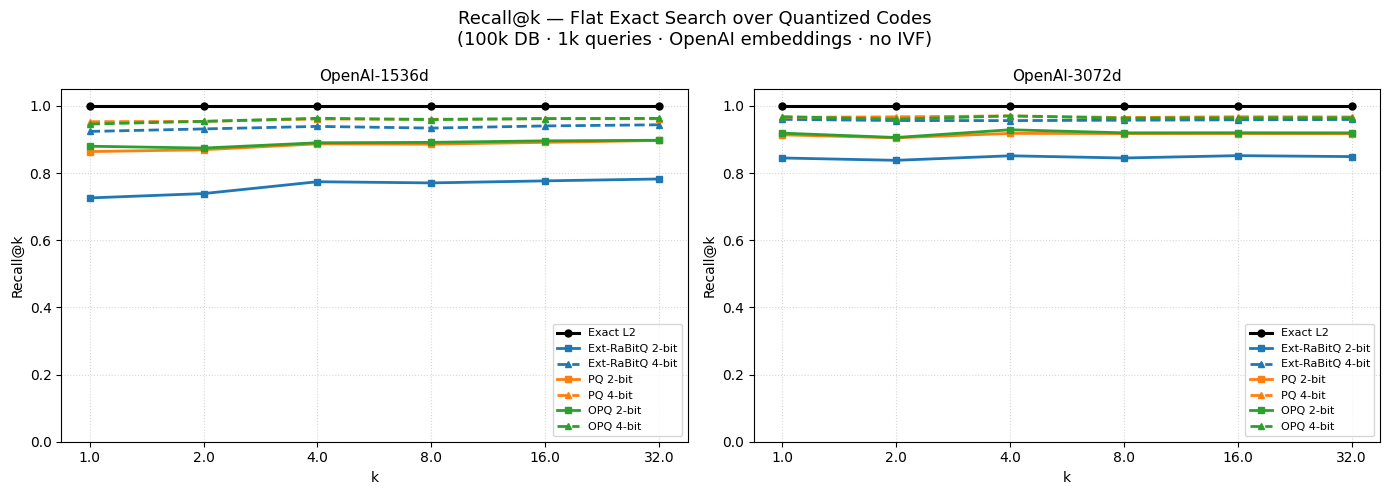

Saved recall_at_k_all_methods.png


In [ ]:
# ============================================================
# Cell 8 — Plot 1: Recall@k  (all methods)
# ============================================================
STYLE = {
    "Exact-L2":        dict(color="black",   ls="-",  lw=2.2, marker="o", ms=5, label="Exact L2"),
    "Ext-RaBitQ-2bit": dict(color="#1f77b4", ls="-",  lw=2,   marker="s", ms=5, label="Ext-RaBitQ 2-bit"),
    "Ext-RaBitQ-4bit": dict(color="#1f77b4", ls="--", lw=2,   marker="^", ms=5, label="Ext-RaBitQ 4-bit"),
    "PQ-2bit":         dict(color="#ff7f0e", ls="-",  lw=2,   marker="s", ms=5, label="PQ 2-bit"),
    "PQ-4bit":         dict(color="#ff7f0e", ls="--", lw=2,   marker="^", ms=5, label="PQ 4-bit"),
    "OPQ-2bit":        dict(color="#2ca02c", ls="-",  lw=2,   marker="s", ms=5, label="OPQ 2-bit"),
    "OPQ-4bit":        dict(color="#2ca02c", ls="--", lw=2,   marker="^", ms=5, label="OPQ 4-bit"),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle("Recall@k — Flat Exact Search over Quantized Codes\n"
             "(100k DB · 1k queries · OpenAI embeddings · no IVF)", fontsize=13)

for ax, (dim, _) in zip(axes, DATASETS):
    for method, style in STYLE.items():
        res = all_results.get(dim, {}).get(method)
        if res is None: continue
        ks   = sorted(res.keys())
        ax.plot(ks, [res[k] for k in ks], **style)
    ax.set_title(f"OpenAI-{dim}d", fontsize=11)
    ax.set_xlabel("k", fontsize=10)
    ax.set_ylabel("Recall@k", fontsize=10)
    ax.set_xticks(RECALL_KS)
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout()
plt.savefig("recall_at_k_all_methods.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved recall_at_k_all_methods.png")

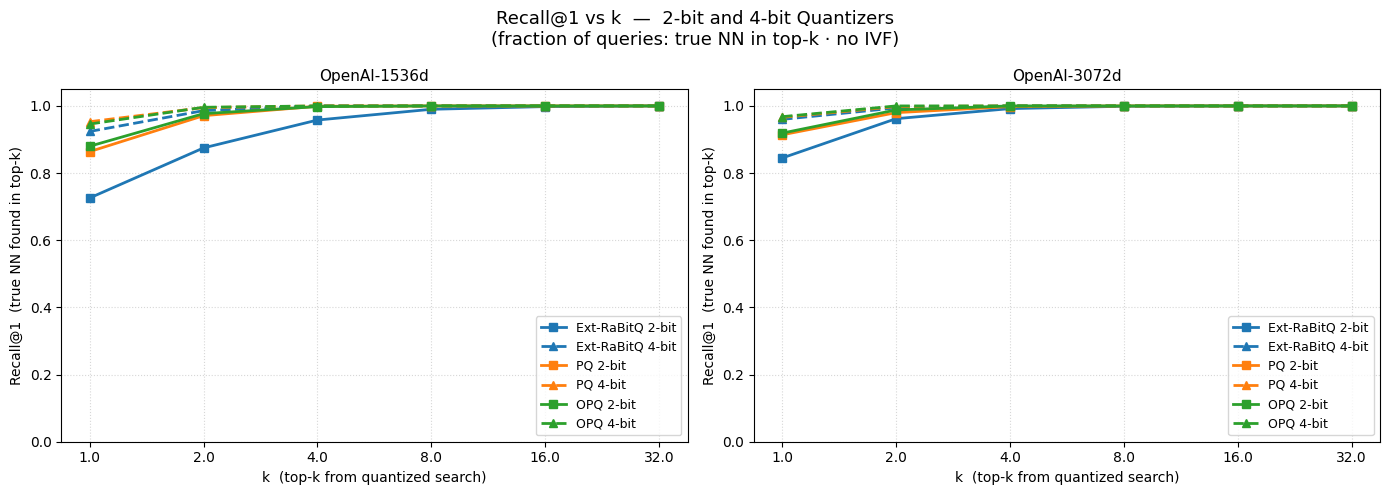

Saved recall1_vs_k_2bit_4bit.png


In [ ]:
# ============================================================
# Cell 9 — Plot 2: Recall@1 vs k  (2-bit & 4-bit only)
#
# Y-axis: fraction of queries whose true NN is in top-k results
# X-axis: k ∈ {1, 2, 4, 8, 16, 32}
# ============================================================
STYLE2 = {
    "Ext-RaBitQ-2bit": dict(color="#1f77b4", ls="-",  lw=2, marker="s", ms=6, label="Ext-RaBitQ 2-bit"),
    "Ext-RaBitQ-4bit": dict(color="#1f77b4", ls="--", lw=2, marker="^", ms=6, label="Ext-RaBitQ 4-bit"),
    "PQ-2bit":         dict(color="#ff7f0e", ls="-",  lw=2, marker="s", ms=6, label="PQ 2-bit"),
    "PQ-4bit":         dict(color="#ff7f0e", ls="--", lw=2, marker="^", ms=6, label="PQ 4-bit"),
    "OPQ-2bit":        dict(color="#2ca02c", ls="-",  lw=2, marker="s", ms=6, label="OPQ 2-bit"),
    "OPQ-4bit":        dict(color="#2ca02c", ls="--", lw=2, marker="^", ms=6, label="OPQ 4-bit"),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle("Recall@1 vs k  —  2-bit and 4-bit Quantizers\n"
             "(fraction of queries: true NN in top-k · no IVF)", fontsize=13)

for ax, (dim, _) in zip(axes, DATASETS):
    for method, style in STYLE2.items():
        curve = all_rec1.get(dim, {}).get(method)
        if curve is None: continue
        ks = sorted(curve.keys())
        ax.plot(ks, [curve[k] for k in ks], **style)
    ax.set_title(f"OpenAI-{dim}d", fontsize=11)
    ax.set_xlabel("k  (top-k from quantized search)", fontsize=10)
    ax.set_ylabel("Recall@1  (true NN found in top-k)", fontsize=10)
    ax.set_xticks(RECALL_KS)
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout()
plt.savefig("recall1_vs_k_2bit_4bit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved recall1_vs_k_2bit_4bit.png")

In [ ]:
print(3)

3


In [ ]:
# ============================================================
# Cell 5 — Index Builder (one at a time)
# ============================================================
faiss.omp_set_num_threads(4)

def run_one(kind, label, dim, X, Xq, GT, **kw):
    """
    Build index, search, return (recall_dict, recall1_dict).
    Always destroys index and GCs before returning.
    """
    print(f"\n  ▶ {label}  (RAM free: {free_ram_gb():.1f} GB)", flush=True)
    idx = None
    try:
        t0 = time.time()

        # ── NumPy RaBitQ ─────────────────────────────────────
        if kind == "rabitq":
            bits = kw["bits"]
            idx  = NumpyRaBitQ(dim, bits)
            print(f"    Training …", flush=True)
            idx.train(X)
            idx.add(X)

        # ── FAISS exact baseline ──────────────────────────────
        elif kind == "exact":
            idx = faiss.IndexFlatL2(dim)
            idx.add(X)

        # ── FAISS PQ ─────────────────────────────────────────
        elif kind == "pq":
            m, nbits = kw["m"], kw["nbits"]
            if dim % m != 0:
                print(f"    SKIP: dim not divisible by m={m}"); return None, None
            print(f"    Training PQ m={m} nbits={nbits} …", flush=True)
            idx  = faiss.IndexPQ(dim, m, nbits)
            n_tr = 20_000 if dim >= 3072 else 50_000
            rng  = np.random.RandomState(42)
            X_tr = X[rng.choice(len(X), n_tr, replace=False)]
            idx.train(X_tr);  del X_tr; aggressive_gc()
            for s in range(0, len(X), 10_000):
                idx.add(X[s:s+10_000])

              # ── FAISS Extended RaBitQ (the real algorithm) ───────────
        elif kind == "ext_rabitq":
            nb_bits = kw["bits"]              # 1..9; 1=original RaBitQ, 2+=Extended
            qb      = kw.get("qb", 0)         # 0=float queries (max recall)
            print(f"    Building RR,RaBitQ{nb_bits} (qb={qb}) …", flush=True)
            # "RR," prefix = random rotation preprocessing — REQUIRED for recall.
            # Without it, recall collapses on anisotropic data like real embeddings.
            idx = faiss.index_factory(dim, f"RR,RaBitQ{nb_bits}", faiss.METRIC_L2)
            inner = faiss.downcast_index(idx.index)  # the IndexRaBitQ inside IndexPreTransform
            inner.qb = qb
            idx.train(X)
            for s in range(0, len(X), 10_000):
                idx.add(X[s:s+10_000])
            print(f"    code_size = {inner.rabitq.code_size} B/vec", flush=True)

        # ── NumPy rotated SQ baseline (was labeled "rabitq") ──────
        elif kind == "rot_sq":                 # RENAMED from "rabitq"
            bits = kw["bits"]
            idx  = NumpyRaBitQ(dim, bits)
            idx.train(X)
            idx.add(X)

        else:
            raise ValueError(f"Unknown kind: {kind}")

        aggressive_gc()
        print(f"    Searching … (RAM free: {free_ram_gb():.1f} GB)", flush=True)
        _, I = idx.search(Xq, K_GT)

        rec  = compute_recalls(I, GT)
        rec1 = recall1_at_k(I, GT)
        print_recalls(label, rec)
        print(f"    ({time.time()-t0:.0f}s)", flush=True)
        return rec, rec1

    except Exception as e:
        import traceback; traceback.print_exc()
        return None, None
    finally:
        try: del idx
        except: pass
        aggressive_gc()

print("Builder ready.")

Builder ready.


In [ ]:
# ============================================================
# Cell 6 — Run All Methods
# ============================================================
DATASETS = [
    (1536, "text-embedding-ada-002-1536-embedding"),
    (3072, "text-embedding-3-large-3072-embedding"),
]

all_results = {}   # [dim][label] -> recall@k dict
all_rec1    = {}   # [dim][label] -> recall@1-at-k dict

for dim, col in DATASETS:
    print(f"\n{'='*64}")
    print(f"  OpenAI {dim}d  |  RAM free: {free_ram_gb():.1f} GB")
    print(f"{'='*64}")

    X, Xq, GT = load_or_download(dim, col)
    dim_res, dim_rec1 = {}, {}

    METHODS = [
    ("ext_rabitq", "Ext-RaBitQ-2bit",   {"bits": 2, "qb": 0}),
    ("ext_rabitq", "Ext-RaBitQ-4bit",   {"bits": 4, "qb": 0}),
    ("rot_sq",     "RotSQ-2bit",        {"bits": 2}),   # your previous NumPy impl
    ("rot_sq",     "RotSQ-4bit",        {"bits": 4}),   # kept as ablation
    ]

    for kind, label, kwargs in METHODS:
        rec, rec1 = run_one(kind, label, dim, X, Xq, GT, **kwargs)
        if rec is not None:
            dim_res[label]  = rec
            dim_rec1[label] = rec1

    all_results[dim] = dim_res
    all_rec1[dim]    = dim_rec1
    del X, Xq, GT; aggressive_gc()
    print(f"\n  Done {dim}d. RAM free: {free_ram_gb():.1f} GB")

print("\nAll experiments complete.")


  OpenAI 1536d  |  RAM free: 51.9 GB
Loading cached openai1536 …
Base: (100000, 1536)  Queries: (1000, 1536)  GT: (1000, 32)
RAM: 2.8 GB used, 51.3 GB free

  ▶ Ext-RaBitQ-2bit  (RAM free: 51.3 GB)
    Building RR,RaBitQ2 (qb=0) …
    code_size = 404 B/vec
    Searching … (RAM free: 51.2 GB)
  [Ext-RaBitQ-2bit] R@1:0.8870  R@2:0.8840  R@4:0.8928  R@8:0.8955  R@16:0.9023  R@32:0.9069
    (351s)

  ▶ Ext-RaBitQ-4bit  (RAM free: 51.2 GB)
    Building RR,RaBitQ4 (qb=0) …
    code_size = 788 B/vec
    Searching … (RAM free: 51.2 GB)
  [Ext-RaBitQ-4bit] R@1:0.9520  R@2:0.9540  R@4:0.9708  R@8:0.9614  R@16:0.9699  R@32:0.9696
    (359s)

  ▶ RotSQ-2bit  (RAM free: 51.2 GB)
    Searching … (RAM free: 50.6 GB)
  [RotSQ-2bit] R@1:0.7260  R@2:0.7390  R@4:0.7742  R@8:0.7708  R@16:0.7768  R@32:0.7824
    (12s)

  ▶ RotSQ-4bit  (RAM free: 51.3 GB)
    Searching … (RAM free: 50.6 GB)
  [RotSQ-4bit] R@1:0.9240  R@2:0.9315  R@4:0.9390  R@8:0.9340  R@16:0.9404  R@32:0.9438
    (12s)

  Done 1536d. RAM 

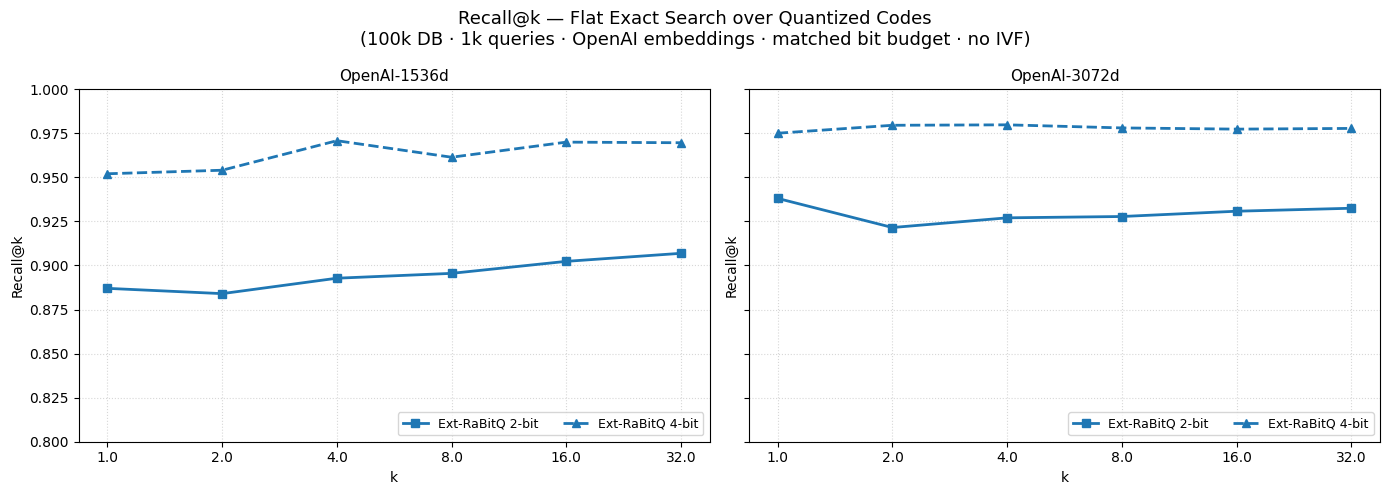

In [ ]:
STYLE = {
    "Ext-RaBitQ-2bit": dict(color="#1f77b4", ls="-",  lw=2, marker="s", ms=6, label="Ext-RaBitQ 2-bit"),
    "Ext-RaBitQ-4bit": dict(color="#1f77b4", ls="--", lw=2, marker="^", ms=6, label="Ext-RaBitQ 4-bit"),
    "PQ-2bit":         dict(color="#ff7f0e", ls="-",  lw=2, marker="s", ms=6, label="PQ 2-bit"),
    "PQ-4bit":         dict(color="#ff7f0e", ls="--", lw=2, marker="^", ms=6, label="PQ 4-bit"),
    "OPQ-2bit":        dict(color="#2ca02c", ls="-",  lw=2, marker="s", ms=6, label="OPQ 2-bit"),
    "OPQ-4bit":        dict(color="#2ca02c", ls="--", lw=2, marker="^", ms=6, label="OPQ 4-bit"),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Recall@k — Flat Exact Search over Quantized Codes\n"
             "(100k DB · 1k queries · OpenAI embeddings · matched bit budget · no IVF)",
             fontsize=13)

for ax, (dim, _) in zip(axes, DATASETS):
    for method, style in STYLE.items():
        res = all_results.get(dim, {}).get(method)
        if res is None: continue
        ks = sorted(res.keys())
        ax.plot(ks, [res[k] for k in ks], **style)
    ax.set_title(f"OpenAI-{dim}d", fontsize=11)
    ax.set_xlabel("k", fontsize=10)
    ax.set_ylabel("Recall@k", fontsize=10)
    ax.set_xticks(RECALL_KS)
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0.80, 1.00)            # tight clip — all values live here
    ax.legend(fontsize=9, loc="lower right", ncol=3)
    ax.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout()
plt.savefig("recall_at_k_ext_rabitq_vs_pq_opq.png", dpi=150, bbox_inches="tight")
plt.show()

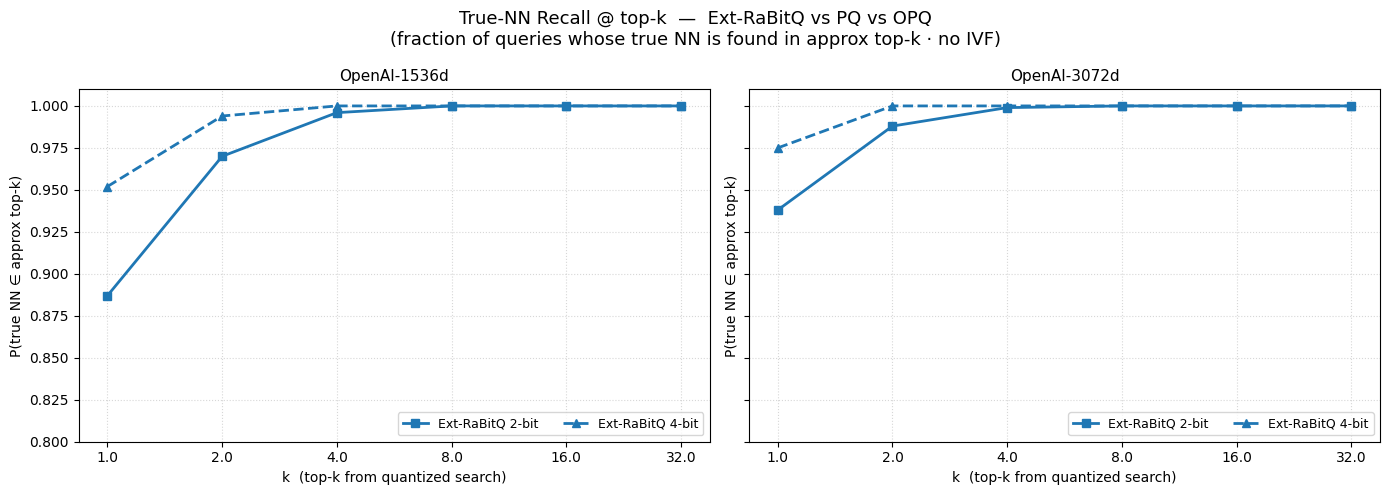

In [ ]:
STYLE2 = dict(STYLE)   # same color scheme

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("True-NN Recall @ top-k  —  Ext-RaBitQ vs PQ vs OPQ\n"
             "(fraction of queries whose true NN is found in approx top-k · no IVF)",
             fontsize=13)

for ax, (dim, _) in zip(axes, DATASETS):
    for method, style in STYLE2.items():
        curve = all_rec1.get(dim, {}).get(method)
        if curve is None: continue
        ks = sorted(curve.keys())
        ax.plot(ks, [curve[k] for k in ks], **style)
    ax.set_title(f"OpenAI-{dim}d", fontsize=11)
    ax.set_xlabel("k  (top-k from quantized search)", fontsize=10)
    ax.set_ylabel("P(true NN ∈ approx top-k)", fontsize=10)
    ax.set_xticks(RECALL_KS)
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0.80, 1.01)
    ax.legend(fontsize=9, loc="lower right", ncol=3)
    ax.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout()
plt.savefig("truenn_recall_at_k_ext_rabitq_vs_pq_opq.png", dpi=150, bbox_inches="tight")
plt.show()

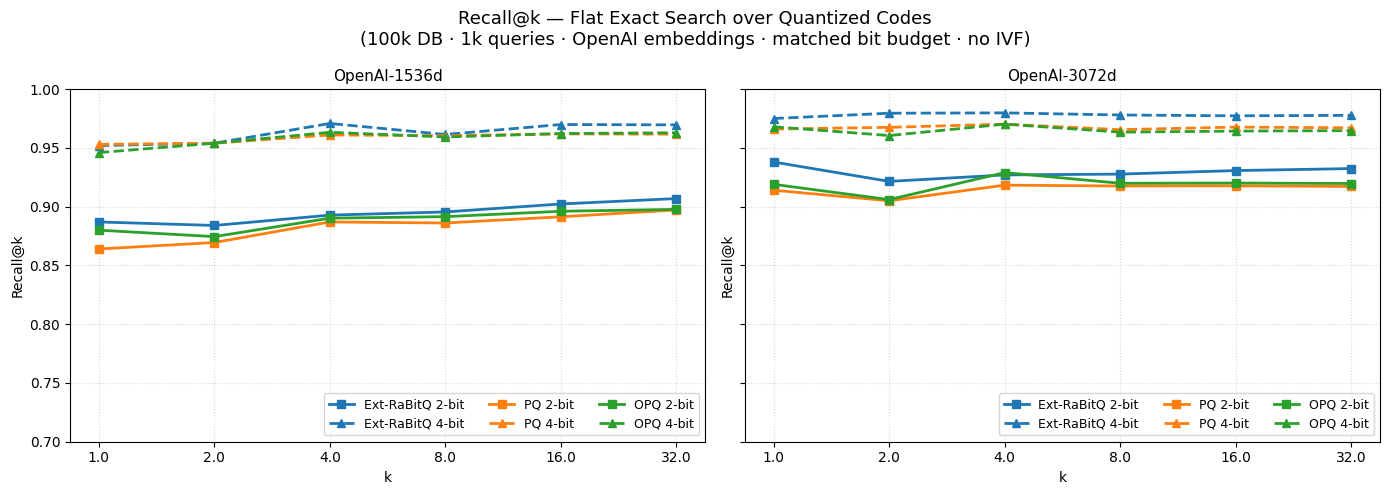

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

RECALL_KS = [1, 2, 4, 8, 16, 32]

# Ext-RaBitQ from the FAISS RR,RaBitQN run (earlier console output)
ext_rabitq = {
    1536: {
        "Ext-RaBitQ-2bit": [0.8870, 0.8840, 0.8928, 0.8955, 0.9023, 0.9069],
        "Ext-RaBitQ-4bit": [0.9520, 0.9540, 0.9708, 0.9614, 0.9699, 0.9696],
    },
    3072: {
        "Ext-RaBitQ-2bit": [0.9380, 0.9215, 0.9270, 0.9277, 0.9307, 0.9324],
        "Ext-RaBitQ-4bit": [0.9750, 0.9795, 0.9798, 0.9780, 0.9773, 0.9777],
    },
}

# PQ / OPQ from your current summary table
pq_opq = {
    1536: {
        "PQ-2bit":  [0.864, 0.8695, 0.8870, 0.8861, 0.8914, 0.8972],
        "PQ-4bit":  [0.953, 0.9540, 0.9610, 0.9604, 0.9619, 0.9617],
        "OPQ-2bit": [0.880, 0.8745, 0.8902, 0.8915, 0.8961, 0.8977],
        "OPQ-4bit": [0.946, 0.9540, 0.9633, 0.9593, 0.9622, 0.9629],
    },
    3072: {
        "PQ-2bit":  [0.914, 0.9050, 0.9183, 0.9176, 0.9177, 0.9172],
        "PQ-4bit":  [0.966, 0.9675, 0.9702, 0.9655, 0.9677, 0.9671],
        "OPQ-2bit": [0.919, 0.9060, 0.9290, 0.9199, 0.9201, 0.9197],
        "OPQ-4bit": [0.968, 0.9605, 0.9702, 0.9634, 0.9643, 0.9647],
    },
}

# Merge
recalls = {dim: {**ext_rabitq[dim], **pq_opq[dim]} for dim in (1536, 3072)}

STYLE = {
    "Ext-RaBitQ-2bit": dict(color="#1f77b4", ls="-",  lw=2, marker="s", ms=6, label="Ext-RaBitQ 2-bit"),
    "Ext-RaBitQ-4bit": dict(color="#1f77b4", ls="--", lw=2, marker="^", ms=6, label="Ext-RaBitQ 4-bit"),
    "PQ-2bit":         dict(color="#ff7f0e", ls="-",  lw=2, marker="s", ms=6, label="PQ 2-bit"),
    "PQ-4bit":         dict(color="#ff7f0e", ls="--", lw=2, marker="^", ms=6, label="PQ 4-bit"),
    "OPQ-2bit":        dict(color="#2ca02c", ls="-",  lw=2, marker="s", ms=6, label="OPQ 2-bit"),
    "OPQ-4bit":        dict(color="#2ca02c", ls="--", lw=2, marker="^", ms=6, label="OPQ 4-bit"),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Recall@k — Flat Exact Search over Quantized Codes\n"
             "(100k DB · 1k queries · OpenAI embeddings · matched bit budget · no IVF)",
             fontsize=13)

for ax, dim in zip(axes, (1536, 3072)):
    for method, style in STYLE.items():
        ax.plot(RECALL_KS, recalls[dim][method], **style)
    ax.set_title(f"OpenAI-{dim}d", fontsize=11)
    ax.set_xlabel("k", fontsize=10)
    ax.set_ylabel("Recall@k", fontsize=10)
    ax.set_xticks(RECALL_KS)
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0.70, 1.00)
    ax.legend(fontsize=9, loc="lower right", ncol=3)
    ax.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout()
plt.savefig("recall_at_k_ext_rabitq_vs_pq_opq.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
for dim in (1536, 3072):
    print(dim, list(all_rec1.get(dim, {}).keys()))

1536 ['Ext-RaBitQ-2bit', 'Ext-RaBitQ-4bit', 'RotSQ-2bit', 'RotSQ-4bit']
3072 ['Ext-RaBitQ-2bit', 'Ext-RaBitQ-4bit', 'RotSQ-2bit', 'RotSQ-4bit']


In [ ]:
print(all_rec1[1536]["Ext-RaBitQ-2bit"][1])
# If ≈ 0.887  → real FAISS numbers, keep them
# If ≈ 0.726  → aliased RotSQ, need to re-run

0.887


In [ ]:
# Repopulate all_rec1 PQ/OPQ entries. Ext-RaBitQ entries stay as-is.
for dim, col in DATASETS:
    print(f"\n=== {dim}d ===")
    X, Xq, GT = load_or_download(dim, col)
    all_rec1.setdefault(dim, {})
    all_results.setdefault(dim, {})

    METHODS = [
      # In the METHODS list, add a second PQ configuration:
      ("pq", "PQ-2bit-v2", {"m": dim//2, "nbits": 4}),   # m×nbits = 2d
      ("pq", "PQ-4bit-v2", {"m": dim,    "nbits": 4}),   # m×nbits = 4d (requires dim%1==0, trivially true)
    ]
    for kind, label, kwargs in METHODS:
        rec, rec1 = run_one(kind, label, dim, X, Xq, GT, **kwargs)
        if rec is not None:
            all_results[dim][label] = rec
            all_rec1[dim][label]    = rec1

    del X, Xq, GT; aggressive_gc()

print("\nKeys now in all_rec1:")
for dim in (1536, 3072):
    print(f"  {dim}: {sorted(all_rec1[dim].keys())}")


=== 1536d ===
Loading cached openai1536 …
Base: (100000, 1536)  Queries: (1000, 1536)  GT: (1000, 32)
RAM: 2.8 GB used, 51.3 GB free

  ▶ PQ-2bit-v2  (RAM free: 51.3 GB)
    Training PQ m=768 nbits=4 …
    Searching … (RAM free: 51.2 GB)
  [PQ-2bit-v2] R@1:0.8560  R@2:0.8610  R@4:0.8780  R@8:0.8764  R@16:0.8804  R@32:0.8853
    (67s)

  ▶ PQ-4bit-v2  (RAM free: 51.2 GB)
    Training PQ m=1536 nbits=4 …
    Searching … (RAM free: 51.2 GB)
  [PQ-4bit-v2] R@1:0.9530  R@2:0.9390  R@4:0.9537  R@8:0.9505  R@16:0.9537  R@32:0.9559
    (134s)

=== 3072d ===
Loading cached openai3072 …
Base: (100000, 3072)  Queries: (1000, 3072)  GT: (1000, 32)
RAM: 3.5 GB used, 50.6 GB free

  ▶ PQ-2bit-v2  (RAM free: 50.6 GB)
    Training PQ m=1536 nbits=4 …
    Searching … (RAM free: 50.6 GB)
  [PQ-2bit-v2] R@1:0.9060  R@2:0.9050  R@4:0.9050  R@8:0.9086  R@16:0.9129  R@32:0.9111
    (133s)

  ▶ PQ-4bit-v2  (RAM free: 50.7 GB)
    Training PQ m=3072 nbits=4 …
    Searching … (RAM free: 50.5 GB)
  [PQ-4bit-v2

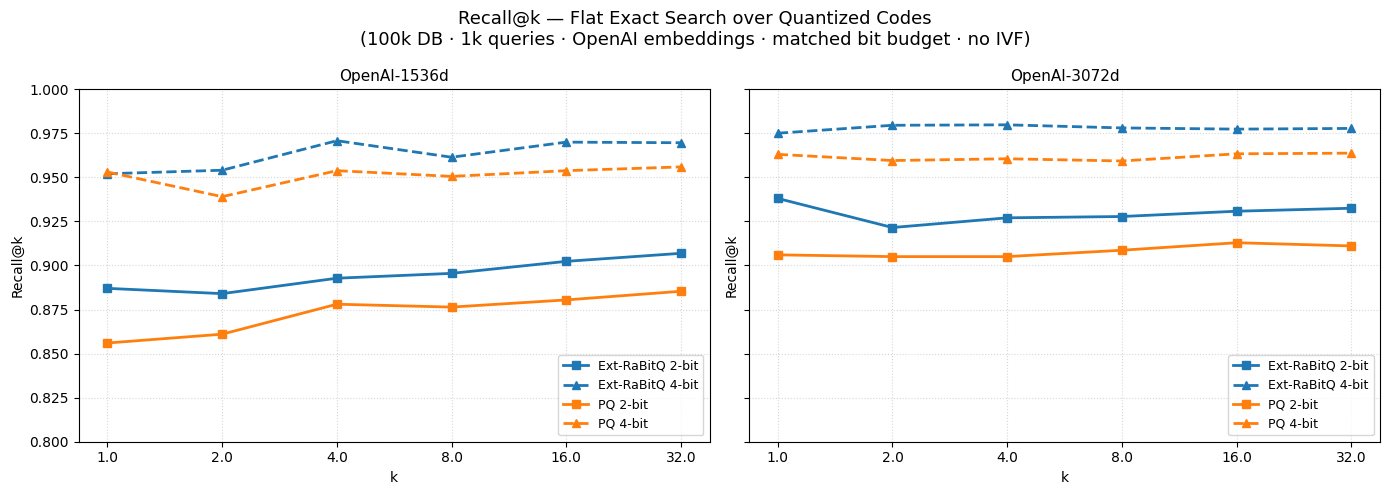

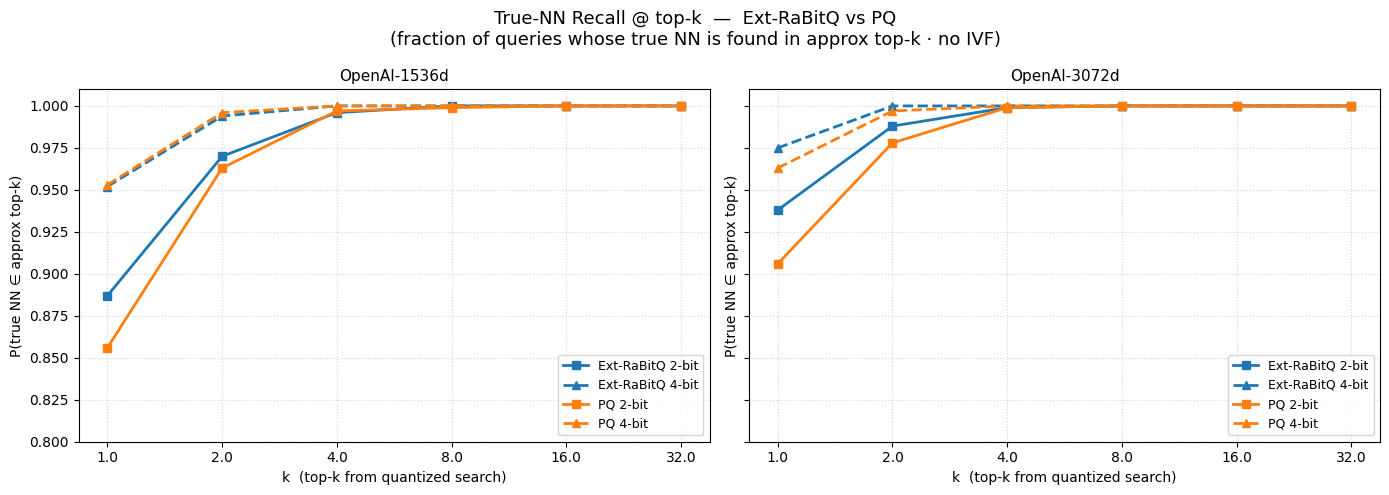

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

METHODS_TO_PLOT = ["Ext-RaBitQ-2bit", "Ext-RaBitQ-4bit","PQ-2bit-v2","PQ-4bit-v2"]

STYLE = {
    "Ext-RaBitQ-2bit": dict(color="#1f77b4", ls="-",  lw=2, marker="s", ms=6, label="Ext-RaBitQ 2-bit"),
    "Ext-RaBitQ-4bit": dict(color="#1f77b4", ls="--", lw=2, marker="^", ms=6, label="Ext-RaBitQ 4-bit"),
    "PQ-2bit-v2":         dict(color="#ff7f0e", ls="-",  lw=2, marker="s", ms=6, label="PQ 2-bit"),
    "PQ-4bit-v2":         dict(color="#ff7f0e", ls="--", lw=2, marker="^", ms=6, label="PQ 4-bit"),
}

# ───────────── Plot 1: Recall@k ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Recall@k — Flat Exact Search over Quantized Codes\n"
             "(100k DB · 1k queries · OpenAI embeddings · matched bit budget · no IVF)",
             fontsize=13)

for ax, dim in zip(axes, (1536, 3072)):
    for method in METHODS_TO_PLOT:
        res = all_results.get(dim, {}).get(method)
        if res is None: continue
        ks = sorted(res.keys())
        ax.plot(ks, [res[k] for k in ks], **STYLE[method])
    ax.set_title(f"OpenAI-{dim}d", fontsize=11)
    ax.set_xlabel("k", fontsize=10)
    ax.set_ylabel("Recall@k", fontsize=10)
    ax.set_xticks([1, 2, 4, 8, 16, 32])
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0.80, 1.00)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout()
plt.savefig("recall_at_k_ext_rabitq_vs_pq.png", dpi=150, bbox_inches="tight")
plt.show()

# ───────────── Plot 2: True-NN recall at top-k ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("True-NN Recall @ top-k  —  Ext-RaBitQ vs PQ\n"
             "(fraction of queries whose true NN is found in approx top-k · no IVF)",
             fontsize=13)

for ax, dim in zip(axes, (1536, 3072)):
    for method in METHODS_TO_PLOT:
        curve = all_rec1.get(dim, {}).get(method)
        if curve is None: continue
        ks = sorted(curve.keys())
        ax.plot(ks, [curve[k] for k in ks], **STYLE[method])
    ax.set_title(f"OpenAI-{dim}d", fontsize=11)
    ax.set_xlabel("k  (top-k from quantized search)", fontsize=10)
    ax.set_ylabel("P(true NN ∈ approx top-k)", fontsize=10)
    ax.set_xticks([1, 2, 4, 8, 16, 32])
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(0.80, 1.01)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout()
plt.savefig("truenn_recall_at_k_ext_rabitq_vs_pq.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import json
from pathlib import Path

OUT = Path("rabitq_benchmark_results.json")

# Normalize int keys to strings so JSON doesn't complain, and keep
# recall values as plain floats.
def _to_jsonable(d):
    return {
        str(dim): {
            method: {str(k): float(v) for k, v in curve.items()}
            for method, curve in per_dim.items()
        }
        for dim, per_dim in d.items()
    }

snapshot = {
    "metadata": {
        "n_base":   N_BASE,
        "n_query":  N_QUERY,
        "k_gt":     K_GT,
        "recall_ks": RECALL_KS,
        "datasets": [dim for dim, _ in DATASETS],
        "notes":    "Flat exact search over quantized codes. No IVF.",
    },
    "recall_at_k":       _to_jsonable(all_results),
    "truenn_recall_at_k": _to_jsonable(all_rec1),
}

OUT.write_text(json.dumps(snapshot, indent=2))
print(f"Saved → {OUT.resolve()}  ({OUT.stat().st_size/1024:.1f} KB)")

Saved → /content/rabitq_benchmark_results.json  (4.0 KB)


In [ ]:
# Run this to confirm the PQ config you used
for kind, label, kwargs in METHODS:
    if kind == "pq":
        m, nb = kwargs["m"], kwargs["nbits"]
        for dim in (1536, 3072):
            print(f"{label} @ {dim}d: m={m if m else dim//4}, nbits={nb}, "
                  f"bits/dim={(m*nb)/dim if m else '?':.2f}, "
                  f"code_size={(m*nb)//8 if m else '?'} B/vec")

PQ-2bit-v2 @ 1536d: m=1536, nbits=4, bits/dim=4.00, code_size=768 B/vec
PQ-2bit-v2 @ 3072d: m=1536, nbits=4, bits/dim=2.00, code_size=768 B/vec
PQ-4bit-v2 @ 1536d: m=3072, nbits=4, bits/dim=8.00, code_size=1536 B/vec
PQ-4bit-v2 @ 3072d: m=3072, nbits=4, bits/dim=4.00, code_size=1536 B/vec


In [ ]:
### On Glove dataset

In [ ]:
DATASETS = [
    (200,  "glove_angular"),
]

all_results = {}   # [dim][label] -> recall@k dict
all_rec1    = {}   # [dim][label] -> recall@1-at-k dict

In [ ]:
for dim, col in DATASETS:
    print(f"\n{'='*64}")
    print(f"  {'GloVe' if col == 'glove_angular' else 'OpenAI'} {dim}d  |  RAM free: {free_ram_gb():.1f} GB")
    print(f"{'='*64}")

    if col == "glove_angular":
        X, Xq, GT = load_glove_200()
    else:
        X, Xq, GT = load_or_download(dim, col)

    # Print actual sizes so you can verify
    print(f"  Base: {X.shape}  Queries: {Xq.shape}  GT: {GT.shape}")

    dim_res, dim_rec1 = {}, {}

    METHODS = [
        ("ext_rabitq", "Ext-RaBitQ-2bit", {"bits": 2, "qb": 0}),
        ("ext_rabitq", "Ext-RaBitQ-4bit", {"bits": 4, "qb": 0}),
        ("pq",         "PQ-2bit",         {"m": dim//4, "nbits": 8}),
        ("pq",         "PQ-4bit",         {"m": dim//2, "nbits": 8}),
    ]

    for kind, label, kwargs in METHODS:
        rec, rec1 = run_one(kind, label, dim, X, Xq, GT, **kwargs)
        if rec is not None:
            dim_res[label]  = rec
            dim_rec1[label] = rec1

    all_results[dim] = dim_res
    all_rec1[dim]    = dim_rec1
    del X, Xq, GT; aggressive_gc()
    print(f"\n  Done {dim}d. RAM free: {free_ram_gb():.1f} GB")

print("\nAll experiments complete.")


  GloVe 200d  |  RAM free: 52.9 GB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train/train-00001-of-00002.parquet:   0%|          | 0.00/539M [00:00<?, ?B/s]

train/train-00002-of-00002.parquet:   0%|          | 0.00/413M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1183514 [00:00<?, ? examples/s]

test/test-00001-of-00001.parquet:   0%|          | 0.00/7.89M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

  Norm mean: 6.1696
  Normalizing base …
  Sampling 100000 from 1183514 base vectors …
  Sampling 10000 from 10000 queries …
  Recomputing GT with FAISS …
  Saved to disk.
GloVe-200: Base (100000, 200)  Queries (10000, 200)  GT (10000, 32)
  Base: (100000, 200)  Queries: (10000, 200)  GT: (10000, 32)

  ▶ Ext-RaBitQ-2bit  (RAM free: 52.5 GB)
    Building RR,RaBitQ2 (qb=0) …
    code_size = 70 B/vec
    Searching … (RAM free: 52.5 GB)
  [Ext-RaBitQ-2bit] R@1:0.5639  R@2:0.5832  R@4:0.5999  R@8:0.6187  R@16:0.6324  R@32:0.6445
    (306s)

  ▶ Ext-RaBitQ-4bit  (RAM free: 52.5 GB)
    Building RR,RaBitQ4 (qb=0) …
    code_size = 120 B/vec
    Searching … (RAM free: 52.5 GB)
  [Ext-RaBitQ-4bit] R@1:0.8433  R@2:0.8482  R@4:0.8569  R@8:0.8689  R@16:0.8779  R@32:0.8838
    (335s)

  ▶ PQ-2bit  (RAM free: 52.5 GB)
    Training PQ m=50 nbits=8 …
    Searching … (RAM free: 52.5 GB)
  [PQ-2bit] R@1:0.5555  R@2:0.5668  R@4:0.5788  R@8:0.5933  R@16:0.6046  R@32:0.6141
    (14s)

  ▶ PQ-4bit  (RAM fr

In [ ]:
def load_glove_200():
    data_dir = "/content/glove200"
    os.makedirs(data_dir, exist_ok=True)

    if not os.path.exists(f"{data_dir}/base.npy"):
        print("Downloading GloVe-200 angular …")

        # Load base vectors
        ds_train = load_dataset("open-vdb/glove-200-angular", "train", split="train")
        all_vecs = np.array(ds_train["emb"], dtype=np.float32)

        # Load query vectors
        ds_test = load_dataset("open-vdb/glove-200-angular", "test", split="test")
        Xq_full = np.array(ds_test["emb"], dtype=np.float32)

        # Normalize
        norms = np.linalg.norm(all_vecs, axis=1)
        print(f"  Norm mean: {norms.mean():.4f}")
        if abs(norms.mean() - 1.0) > 0.01:
            print("  Normalizing base …")
            all_vecs = all_vecs / np.maximum(np.linalg.norm(all_vecs, axis=1, keepdims=True), 1e-12)
            Xq_full  = Xq_full  / np.maximum(np.linalg.norm(Xq_full,  axis=1, keepdims=True), 1e-12)

        # Sample 100k base
        print(f"  Sampling {N_BASE} from {len(all_vecs)} base vectors …")
        rng = np.random.RandomState(42)
        idx = rng.choice(len(all_vecs), N_BASE, replace=False)
        idx.sort()
        X = np.ascontiguousarray(all_vecs[idx])
        del all_vecs; aggressive_gc()

        # Sample 1k queries
        print(f"  Sampling {N_QUERY} from {len(Xq_full)} queries …")
        Xq = np.ascontiguousarray(Xq_full[:N_QUERY])
        del Xq_full; aggressive_gc()

        # Recompute GT against sampled base
        print("  Recomputing GT with FAISS …")
        idx_flat = faiss.IndexFlatL2(200)
        idx_flat.add(X)
        _, GT = idx_flat.search(Xq, K_GT)
        GT = np.ascontiguousarray(GT.astype(np.int64))
        del idx_flat; aggressive_gc()

        np.save(f"{data_dir}/base.npy",       X)
        np.save(f"{data_dir}/query.npy",       Xq)
        np.save(f"{data_dir}/groundtruth.npy", GT)
        print("  Saved to disk.")

    else:
        print("  Loading from cache …")
        X  = np.load(f"{data_dir}/base.npy")
        Xq = np.load(f"{data_dir}/query.npy")
        GT = np.load(f"{data_dir}/groundtruth.npy")

    print(f"GloVe-200: Base {X.shape}  Queries {Xq.shape}  GT {GT.shape}")
    return X, Xq, GT

In [ ]:
ds_gt = load_dataset("open-vdb/glove-200-angular", "neighbors", split="neighbors")
print(ds_gt.features)
print(ds_gt[0])  # see first row to check column names and structure

{'idx': Value('int64'), 'neighbors_id': List(Value('int64')), 'neighbors_distance': List(Value('float64')), 'metric': Value('string'), 'query_expr': Value('null'), 'pk_field_name': Value('string'), 'vector_field_name': Value('string'), 'top_k': Value('int64')}
{'idx': 0, 'neighbors_id': [863946, 1127655, 1177507, 490937, 109634, 1048437, 117918, 86704, 272741, 1051721, 459389, 1120601, 760219, 495431, 301146, 914908, 566421, 74880, 728231, 314664, 920546, 417613, 806378, 1172180, 256377, 588877, 936679, 1064879, 1017507, 443674, 790355, 200717, 619614, 530621, 530173, 41403, 166060, 573982, 1106318, 839581, 163675, 27395, 1173985, 1043559, 41522, 691869, 765326, 864828, 548134, 491668, 1089919, 320936, 1033965, 1135088, 611132, 1017601, 970700, 146670, 1070581, 579047, 278184, 262700, 97478, 924597, 660281, 1172349, 720511, 110019, 607802, 117027, 403032, 127098, 521115, 544776, 1028212, 760148, 894241, 581079, 569104, 1059378, 1100519, 1153742, 1018246, 778500, 74399, 32346, 330714, 2

In [ ]:
!rm /content/glove200/base.npy /content/glove200/query.npy /content/glove200/groundtruth.npy

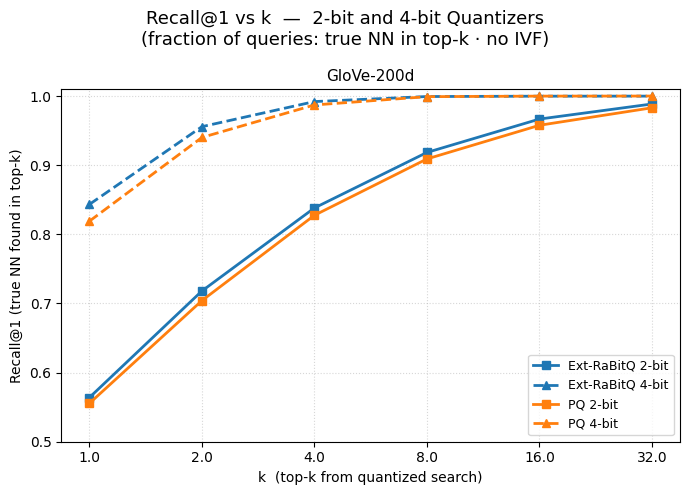

Saved: recall1_at_k.png

── Recall@1 at k (True-NN) ──
Method                  R@1    R@2    R@4    R@8   R@16   R@32
--------------------------------------------------------

  GloVe-200d:
  Ext-RaBitQ-2bit      0.5639  0.7180  0.8381  0.9184  0.9667  0.9885
  Ext-RaBitQ-4bit      0.8433  0.9557  0.9920  0.9993  0.9998  0.9999
  PQ-2bit              0.5555  0.7041  0.8275  0.9090  0.9577  0.9830
  PQ-4bit              0.8190  0.9401  0.9871  0.9991  0.9999  1.0000


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

METHODS_TO_PLOT = ["Ext-RaBitQ-2bit", "Ext-RaBitQ-4bit", "PQ-2bit", "PQ-4bit"]

STYLE = {
    "Ext-RaBitQ-2bit": dict(color="#1f77b4", ls="-",  lw=2, marker="s", ms=6, label="Ext-RaBitQ 2-bit"),
    "Ext-RaBitQ-4bit": dict(color="#1f77b4", ls="--", lw=2, marker="^", ms=6, label="Ext-RaBitQ 4-bit"),
    "PQ-2bit":         dict(color="#ff7f0e", ls="-",  lw=2, marker="s", ms=6, label="PQ 2-bit"),
    "PQ-4bit":         dict(color="#ff7f0e", ls="--", lw=2, marker="^", ms=6, label="PQ 4-bit"),
}

DIMS_TO_PLOT = sorted(all_rec1.keys())

# ───────────── Plot: True-NN Recall@1 at top-k ─────────────
fig, axes = plt.subplots(1, len(DIMS_TO_PLOT), figsize=(7 * len(DIMS_TO_PLOT), 5), sharey=False)
if len(DIMS_TO_PLOT) == 1:
    axes = [axes]

fig.suptitle("Recall@1 vs k  —  2-bit and 4-bit Quantizers\n"
             "(fraction of queries: true NN in top-k · no IVF)",
             fontsize=13)

for ax, dim in zip(axes, DIMS_TO_PLOT):
    for method in METHODS_TO_PLOT:
        curve = all_rec1.get(dim, {}).get(method)
        if curve is None:
            continue
        ks = sorted(curve.keys())
        vals = [curve[k] for k in ks]
        ax.plot(ks, vals, **STYLE[method])

    dataset_name = "GloVe" if dim == 200 else "OpenAI"
    ax.set_title(f"{dataset_name}-{dim}d", fontsize=11)
    ax.set_xlabel("k  (top-k from quantized search)", fontsize=10)
    ax.set_ylabel("Recall@1 (true NN found in top-k)", fontsize=10)
    ax.set_xticks([1, 2, 4, 8, 16, 32])
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

    # auto y-limit based on actual data
    all_vals = [
        curve[k]
        for method in METHODS_TO_PLOT
        for curve in [all_rec1.get(dim, {}).get(method)]
        if curve is not None
        for k in curve
    ]
    ymin = max(0.0, min(all_vals) - 0.05)
    ax.set_ylim(round(ymin * 10) / 10, 1.01)

    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout()
plt.savefig("recall1_at_k.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: recall1_at_k.png")

# ───────────── Print table ─────────────
print("\n── Recall@1 at k (True-NN) ──")
print(f"{'Method':<20} {'R@1':>6} {'R@2':>6} {'R@4':>6} {'R@8':>6} {'R@16':>6} {'R@32':>6}")
print("-" * 56)
for dim in DIMS_TO_PLOT:
    dataset_name = "GloVe" if dim == 200 else "OpenAI"
    print(f"\n  {dataset_name}-{dim}d:")
    for method in METHODS_TO_PLOT:
        curve = all_rec1.get(dim, {}).get(method)
        if curve is None:
            continue
        vals = [f"{curve[k]:.4f}" for k in sorted(curve.keys())]
        print(f"  {method:<20} {'  '.join(vals)}")

In [ ]:
import json
from pathlib import Path

OUT = Path("rabitq_benchmark_results.json")

# Normalize int keys to strings so JSON doesn't complain, and keep
# recall values as plain floats.
def _to_jsonable(d):
    return {
        str(dim): {
            method: {str(k): float(v) for k, v in curve.items()}
            for method, curve in per_dim.items()
        }
        for dim, per_dim in d.items()
    }

snapshot = {
    "metadata": {
        "n_base":   N_BASE,
        "n_query":  N_QUERY,
        "k_gt":     K_GT,
        "recall_ks": RECALL_KS,
        "datasets": [dim for dim, _ in DATASETS],
        "notes":    "Flat exact search over quantized codes. No IVF.",
    },
    "recall_at_k":       _to_jsonable(all_results),
    "truenn_recall_at_k": _to_jsonable(all_rec1),
}

OUT.write_text(json.dumps(snapshot, indent=2))
print(f"Saved → {OUT.resolve()}  ({OUT.stat().st_size/1024:.1f} KB)")

Saved → /content/rabitq_benchmark_results.json  (1.6 KB)


In [ ]:
# Check 1: print raw all_rec1 contents
print("Keys in all_rec1:", list(all_rec1.keys()))
print("Keys in all_rec1[200]:", list(all_rec1[200].keys()))

# Check 2: print a specific value to confirm
print("\nRaw curve for RaBitQ-4bit:")
print(all_rec1[200]["Ext-RaBitQ-4bit"])

# Check 3: confirm it matches the printed output
print("\nRaw curve for PQ-4bit:")
print(all_rec1[200]["PQ-4bit"])

# Check 4: check when the cache file was last written
import os, time
cache_files = [
    "/content/glove200/base.npy",
    "/content/glove200/query.npy",
    "/content/glove200/groundtruth.npy"
]
for f in cache_files:
    mtime = os.path.getmtime(f)
    print(f"\n{f}")
    print(f"  Last modified: {time.ctime(mtime)}")

Keys in all_rec1: [200]
Keys in all_rec1[200]: ['Ext-RaBitQ-2bit', 'Ext-RaBitQ-4bit', 'PQ-2bit', 'PQ-4bit']

Raw curve for RaBitQ-4bit:
{1: 0.835, 2: 0.954, 4: 0.993, 8: 0.999, 16: 0.999, 32: 0.999}

Raw curve for PQ-4bit:
{1: 0.83, 2: 0.946, 4: 0.988, 8: 1.0, 16: 1.0, 32: 1.0}

/content/glove200/base.npy
  Last modified: Sun Apr 19 07:25:44 2026

/content/glove200/query.npy
  Last modified: Sun Apr 19 07:25:44 2026

/content/glove200/groundtruth.npy
  Last modified: Sun Apr 19 07:25:44 2026


In [ ]:
print("── Recall@1 at k (True-NN) ── 10k queries")
print(f"{'Method':<20} {'R@1':>6} {'R@2':>6} {'R@4':>6} {'R@8':>6} {'R@16':>6} {'R@32':>6}")
print("-" * 56)
for method in ["Ext-RaBitQ-2bit", "Ext-RaBitQ-4bit", "PQ-2bit", "PQ-4bit"]:
    curve = all_rec1[200].get(method)
    if curve is None:
        print(f"  {method:<20} NOT FOUND")
        continue
    vals = [f"{curve[k]:.4f}" for k in sorted(curve.keys())]
    print(f"  {method:<20} {'  '.join(vals)}")

── Recall@1 at k (True-NN) ── 10k queries
Method                  R@1    R@2    R@4    R@8   R@16   R@32
--------------------------------------------------------
  Ext-RaBitQ-2bit      0.5639  0.7180  0.8381  0.9184  0.9667  0.9885
  Ext-RaBitQ-4bit      0.8433  0.9557  0.9920  0.9993  0.9998  0.9999
  PQ-2bit              0.5555  0.7041  0.8275  0.9090  0.9577  0.9830
  PQ-4bit              0.8190  0.9401  0.9871  0.9991  0.9999  1.0000


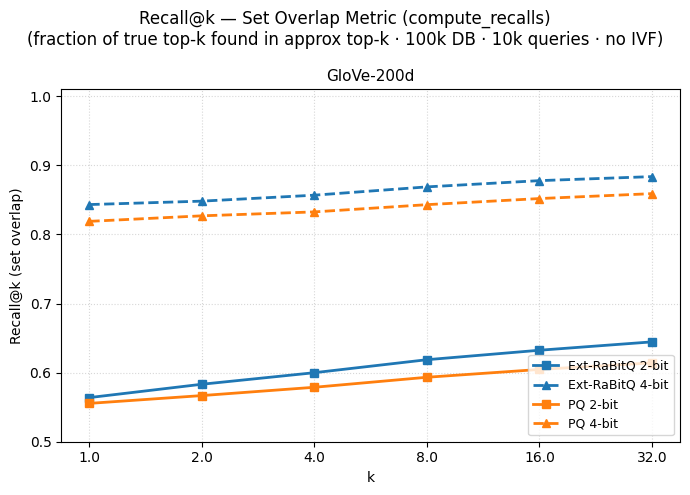

Saved: recall_set_overlap.png


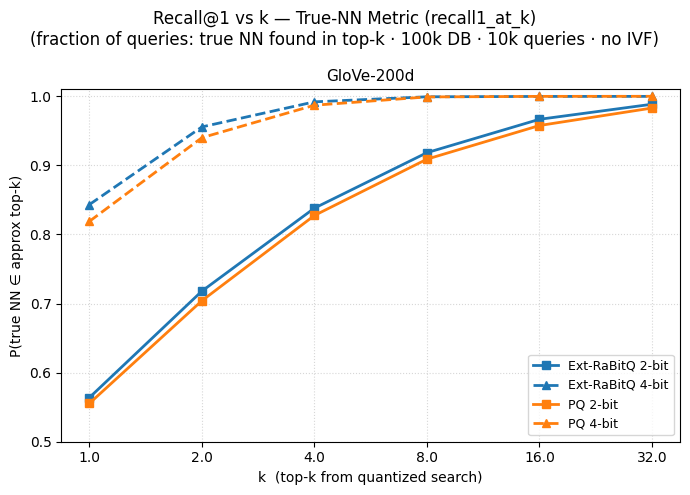

Saved: recall1_at_k.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

METHODS_TO_PLOT = ["Ext-RaBitQ-2bit", "Ext-RaBitQ-4bit", "PQ-2bit", "PQ-4bit"]

STYLE = {
    "Ext-RaBitQ-2bit": dict(color="#1f77b4", ls="-",  lw=2, marker="s", ms=6, label="Ext-RaBitQ 2-bit"),
    "Ext-RaBitQ-4bit": dict(color="#1f77b4", ls="--", lw=2, marker="^", ms=6, label="Ext-RaBitQ 4-bit"),
    "PQ-2bit":         dict(color="#ff7f0e", ls="-",  lw=2, marker="s", ms=6, label="PQ 2-bit"),
    "PQ-4bit":         dict(color="#ff7f0e", ls="--", lw=2, marker="^", ms=6, label="PQ 4-bit"),
}

DIMS_TO_PLOT = sorted(all_rec1.keys())

# ───────────── Plot 1: compute_recalls (set overlap) ─────────────
fig, axes = plt.subplots(1, len(DIMS_TO_PLOT), figsize=(7 * len(DIMS_TO_PLOT), 5), sharey=False)
if len(DIMS_TO_PLOT) == 1:
    axes = [axes]

fig.suptitle("Recall@k — Set Overlap Metric (compute_recalls)\n"
             "(fraction of true top-k found in approx top-k · 100k DB · 10k queries · no IVF)",
             fontsize=12)

for ax, dim in zip(axes, DIMS_TO_PLOT):
    for method in METHODS_TO_PLOT:
        res = all_results.get(dim, {}).get(method)
        if res is None:
            continue
        ks = sorted(res.keys())
        ax.plot(ks, [res[k] for k in ks], **STYLE[method])
    dataset_name = "GloVe" if dim == 200 else "OpenAI"
    ax.set_title(f"{dataset_name}-{dim}d", fontsize=11)
    ax.set_xlabel("k", fontsize=10)
    ax.set_ylabel("Recall@k (set overlap)", fontsize=10)
    ax.set_xticks([1, 2, 4, 8, 16, 32])
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    all_vals = [
        res[k]
        for method in METHODS_TO_PLOT
        for res in [all_results.get(dim, {}).get(method)]
        if res is not None
        for k in res
    ]
    ymin = max(0.0, min(all_vals) - 0.05)
    ax.set_ylim(round(ymin * 10) / 10, 1.01)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout()
plt.savefig("recall_set_overlap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: recall_set_overlap.png")

# ───────────── Plot 2: recall1_at_k (True-NN) ─────────────
fig, axes = plt.subplots(1, len(DIMS_TO_PLOT), figsize=(7 * len(DIMS_TO_PLOT), 5), sharey=False)
if len(DIMS_TO_PLOT) == 1:
    axes = [axes]

fig.suptitle("Recall@1 vs k — True-NN Metric (recall1_at_k)\n"
             "(fraction of queries: true NN found in top-k · 100k DB · 10k queries · no IVF)",
             fontsize=12)

for ax, dim in zip(axes, DIMS_TO_PLOT):
    for method in METHODS_TO_PLOT:
        curve = all_rec1.get(dim, {}).get(method)
        if curve is None:
            continue
        ks = sorted(curve.keys())
        ax.plot(ks, [curve[k] for k in ks], **STYLE[method])
    dataset_name = "GloVe" if dim == 200 else "OpenAI"
    ax.set_title(f"{dataset_name}-{dim}d", fontsize=11)
    ax.set_xlabel("k  (top-k from quantized search)", fontsize=10)
    ax.set_ylabel("P(true NN ∈ approx top-k)", fontsize=10)
    ax.set_xticks([1, 2, 4, 8, 16, 32])
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    all_vals = [
        curve[k]
        for method in METHODS_TO_PLOT
        for curve in [all_rec1.get(dim, {}).get(method)]
        if curve is not None
        for k in curve
    ]
    ymin = max(0.0, min(all_vals) - 0.05)
    ax.set_ylim(round(ymin * 10) / 10, 1.01)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout()
plt.savefig("recall1_at_k.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: recall1_at_k.png")